# US Population Data

Source: https://www.census.gov/data/tables/2020/dec/2020-apportionment-data.html (table 2)

This notebook focuses on a basic statistical analysis of the population of the United States and how people are distributed around the country. This is the second notebook in the overall analysis of the electoral college system. The census data comes from the census website as an .xlsx file, though it was converted to a .csv file to import it as a dataframe using pandas.

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.lines as mlines

I originally used a simple kaggle dataset that had some incorrect population values. In order to retain the code in the other notebooks, I chose to format the census data as if it was the kaggle dataset. (After noticing the sum of the "2020_census" column did not match the official total population, I found that at least two states had differing numbers from the official values: Utah and Illinois.)

Here is the difference in total population counts:

In [2]:
kaggle_data = pd.read_csv("data/us_pop_by_state.csv")
kaggle_data

# the final row has a total value (which is correct and was likely hardcoded)
total_pop_hardcoded = kaggle_data.iat[-1, 3]

pop_col_sum = kaggle_data["2020_census"][:-1].sum()

print(f"Population sum from kaggle column: {pop_col_sum}")
print(f"Kaggle final row total: {total_pop_hardcoded} (matches official count")
print(f"Difference: {total_pop_hardcoded - pop_col_sum}")

Population sum from kaggle column: 331454351
Kaggle final row total: 331449281 (matches official count
Difference: -5070


There was a very small difference in the numbers, but not something that I could overlook. I chose data science for a reason; I'm extremely detail-oriented.

Based on the data being incorrect in at least some instances in the kaggle dataset, I chose to recreate the table with the census data, along with one column from the kaggle dataset (state abbreviations).

Initial import, drop irrelevant rows and columns:

In [3]:
population = pd.read_csv("data/apportionment-2020-census.csv")

# drop irrelevant rows
population = population.iloc[2:]

# create column names from first row of data
population.columns = population.iloc[0]

# drop first row of values (used to be the column names)
population = population.iloc[1:]

# drop last column
population = population.drop(columns=["This cell is intentionally blank."])

# drop final rows, total population can be calculated when needed
population = population.iloc[:-4]

population

2,AREA,"RESIDENT POPULATION (APRIL 1, 2020)"
3,Alabama,"5,024,279"
4,Alaska,"733,391"
5,Arizona,"7,151,502"
6,Arkansas,"3,011,524"
7,California,"39,538,223"
8,Colorado,"5,773,714"
9,Connecticut,"3,605,944"
10,Delaware,"989,948"
11,District of Columbia,"689,545"
12,Florida,"21,538,187"


Convert string values:

In [4]:
# population values are dtype 'string', need numeric values for analysis

# replace commas with an empty string
population["RESIDENT POPULATION (APRIL 1, 2020)"] = population["RESIDENT POPULATION (APRIL 1, 2020)"].str.replace(',', '', regex=True)

# convert to numeric after removing commas
population["RESIDENT POPULATION (APRIL 1, 2020)"] = pd.to_numeric(population["RESIDENT POPULATION (APRIL 1, 2020)"])

# verify correct column data types
population.dtypes

2
AREA                                     str
RESIDENT POPULATION (APRIL 1, 2020)    int64
dtype: object

Sort population column and rename columns for notebook consistency:

In [5]:
# order population descending
population = population.sort_values(by="RESIDENT POPULATION (APRIL 1, 2020)", ascending=False)

# reset index
population = population.reset_index(drop=True)

# add 'rank' column
population["rank"] = range(1, len(population) + 1)

# rename columns
population = population.rename(columns={"RESIDENT POPULATION (APRIL 1, 2020)": "2020_census"})
population = population.rename(columns={"AREA": "state"})

population

2,state,2020_census,rank
0,California,39538223,1
1,Texas,29145505,2
2,Florida,21538187,3
3,New York,20201249,4
4,Pennsylvania,13002700,5
5,Illinois,12812508,6
6,Ohio,11799448,7
7,Georgia,10711908,8
8,North Carolina,10439388,9
9,Michigan,10077331,10


Create new columns: calculate percentage of population and merge state abbreviations from kaggle dataset

In [6]:
# create column: percentage of population of each state
population["percent_of_total"] = round(population["2020_census"] / population["2020_census"].sum(), 4)

# get state codes from other csv file (not used because some population values were incorrect)
state_code = pd.read_csv("data/us_pop_by_state.csv", usecols=["state_code"])

# drop the final row
state_code = state_code[:-1]

# merge with population table
population = population.merge(state_code, left_index=True, right_index=True, how="inner")

Reoder columns and rename one state value:

In [7]:
# reorder columns for better readability
col_order = ["rank", "state", "state_code", "2020_census", "percent_of_total"]

population = population[col_order]

# rename District of Columbia to DC (for consistency in other notebooks)
population.loc[population["state"] == "District of Columbia", "state"] = "DC"

# population

Save new table to csv file to use in other notebooks:

In [8]:
# uncomment to save the file
population.to_csv("data/census_data.csv")

## Basic Table Info and Statistics

In [9]:
population.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              51 non-null     int64  
 1   state             51 non-null     str    
 2   state_code        51 non-null     str    
 3   2020_census       51 non-null     int64  
 4   percent_of_total  51 non-null     float64
dtypes: float64(1), int64(2), str(2)
memory usage: 2.1 KB


In [10]:
population.describe()

,rank,2020_census,percent_of_total
count,51.000000,5.100000e+01,51.000000
mean,26.000000,6.499006e+06,0.019608
std,14.866069,7.408023e+06,0.022347
min,1.000000,5.768510e+05,0.001700
25%,13.500000,1.816411e+06,0.005450
50%,26.000000,4.505836e+06,0.013600
75%,38.500000,7.428392e+06,0.022400
max,51.000000,3.953822e+07,0.119300


In [11]:
# total population
total_pop = population["2020_census"].sum()
print(total_pop)

331449281


In [12]:
# save the mean, median values of population (2020_census) for analysis
median_pop = population["2020_census"].median()
mean_pop = round(population["2020_census"].mean(), 2)

# print("Number of people per state:")
print(f"Median: {median_pop}")
print(f"Mean: {mean_pop}")

Median: 4505836.0
Mean: 6499005.51


## Visualize State Population

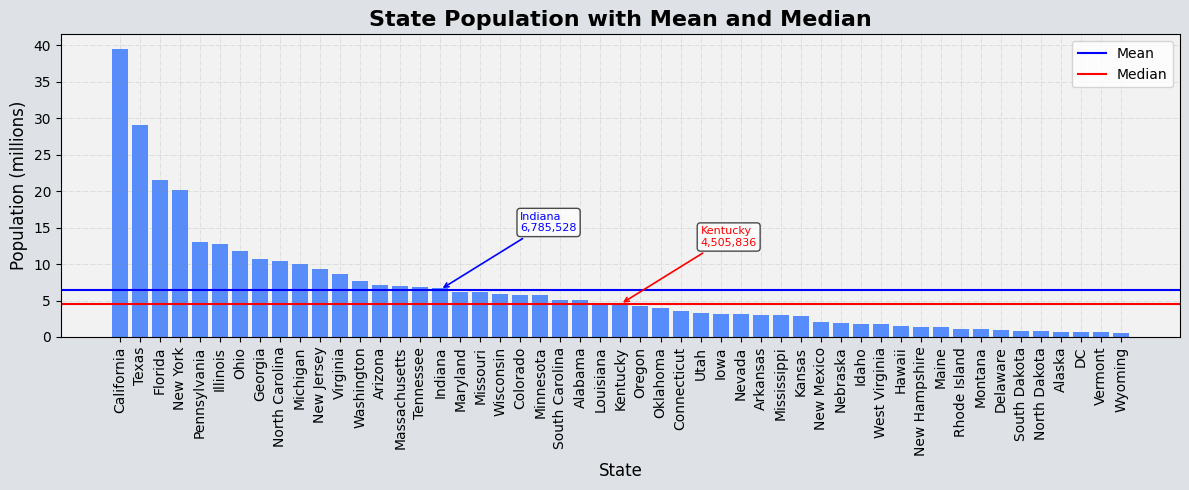

In [13]:
# value counts
x = population["state"]
y = population["2020_census"] / 1000000 # simplifies the y-axis range of values

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#DEE2E6")
ax.set_facecolor('#F2F2F2')

plt.ticklabel_format(axis='y', style='plain')

plt.bar(x, y)

# horizontal lines to show mean and median values
ax.axhline(mean_pop / 1000000, color="blue")
ax.axhline(median_pop / 1000000, color="red")

ax.set_xticks(range(51))
ax.set_xticklabels(x, rotation=90, ha="center")
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Population (millions)", fontsize=12)
ax.set_title('State Population with Mean and Median', fontsize=16, fontweight="bold")
ax.grid(alpha=0.3, linestyle='-.', color="#889696")

# proxy legend to show what each line represents
mean_line = mlines.Line2D([], [], color='blue', label='Mean')
med_line = mlines.Line2D([], [], color='red', label='Median')

ax.legend(handles=[mean_line, med_line])

# annotate the values where the mean and median match the closest to a state's population
arrowprops = dict(arrowstyle="->", lw=1.2)

for value, color, label in [
    (mean_pop, "blue", "Mean"),
    (median_pop, "red", "Median"),
]:
    # find the state whose population is closest to each line
    closest_idx = (population["2020_census"] - value).abs().idxmin()

    # get its integer x-axis position
    x_pos = population.index.get_loc(closest_idx)

    state_name = population.loc[closest_idx, "state"]
    state_pop = population.loc[closest_idx, "2020_census"]

    ax.annotate(
        f"{state_name}\n{state_pop:,.0f}",
        xy=(x_pos, value / 1000000),          # tip of arrow: on the line
        xytext=(x_pos + 4, value / 1000000 + 8),  # text offset
        fontsize=8,
        color=color,
        arrowprops={**arrowprops, "color": color},
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
    )

plt.tight_layout()
plt.show()

### Boxplot Visualization

Visualize the distribution of state populations, define the Interquartile Range (IQR), and highlight the outliers within this dataset.

In [14]:
y = population["2020_census"] / 1000000 # simplifies the y-axis range of values

# calculate outlier bounds using the same rule matplotlib uses (1.5 * IQR)
q1, q3 = y.quantile(0.25), y.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

print(upper_bound)
print(lower_bound)

15.846362249999999
-6.601559749999998


In [15]:
# filter to only high outliers (low outliers would be less than a negative population of 6.6 million)
outliers = (population["2020_census"] / 1000000) > upper_bound
outliers

0      True
1      True
2      True
3      True
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
50    False
Name: 2020_census, dtype: bool

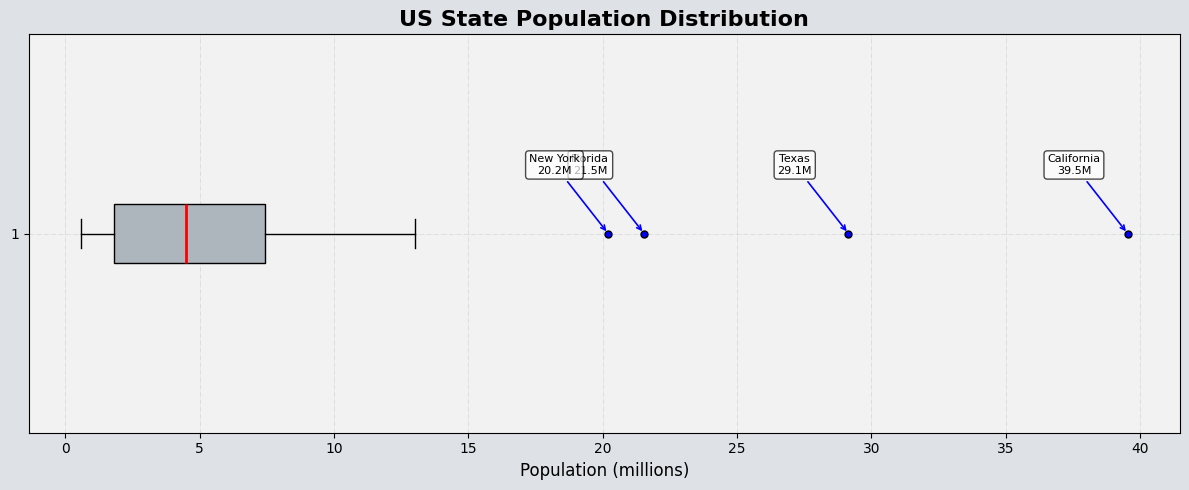

In [16]:
# population values
y = population["2020_census"] / 1000000 # simplifies the y-axis range of values

# define and filter outliers
outlier_mask = y > upper_bound
outliers = population[outlier_mask].copy()
outliers["pop_millions"] = y[outlier_mask].values

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#DEE2E6")
ax.set_facecolor('#F2F2F2')

ax.boxplot(y, vert=False, patch_artist=True,
           boxprops=dict(facecolor="#ADB5BD"),
           medianprops=dict(color="red", linewidth=2),
           flierprops=dict(marker="o", markerfacecolor="blue", markersize=5))

# annotate each outlier
for _, row in outliers.iterrows():
    ax.annotate(
        f"{row['state']}\n{row['pop_millions']:.1f}M",
        xy=(row["pop_millions"], 1),         # arrowhead: at the flier point (y=1, the single box position)
        xytext=(row["pop_millions"] - 2, 1.15),  # text offset: above and slightly left
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="blue", lw=1.2),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
        ha="center",
    )

ax.set_xlabel("Population (millions)", fontsize=12)
ax.set_title("US State Population Distribution", fontsize=16, fontweight="bold")
ax.grid(alpha=0.3, linestyle='-.', color="#889696")

plt.tight_layout()
plt.show()

The boxplot shows the overall skew that the four states with the highest populations have to the distribution of population. The red line in the box is the median population, which we calculated to approximately 4.5 million. The box itself shows the range of the middle 50% of the state's populations. The left 'whisker' is the minimum population (Wyoming). The right 'whisker' is the highest value that is considered 'within normal range' (Pennsylvania, with a population just over 13 million). The four dots are the states that fall outside the majority of the values, which are quite high outliers.

Although they are outliers, the populations in these states are crucial to understanding the dynamic of the United States population. The mean and median populations are low in comparison, but show that the majority of the states have between 1.5 million and 7 million people. Keeping this in mind when we are going through the electoral college analysis will be key in understanding how the voting power of each state changes based on its population and the amount of representation it has in a presidential election.

### Top Four States by Population

In [17]:
# population of the top four states combined
top_4_pop = population["2020_census"][:4].sum()

# percentage of population of top four states combined
top_4_percent = population["percent_of_total"][:4].sum() * 100 # creates percentage instead of decimal

print(f"The four top states are:\n {population[:4]}\n")
print(f"The top four states combined: {top_4_pop:.1f}M")

print(f"The top four states combined percentage: {top_4_percent:.1f}%")


The four top states are:
    rank       state state_code  2020_census  percent_of_total
0     1  California         CA     39538223            0.1193
1     2       Texas         TX     29145505            0.0879
2     3     Florida         FL     21538187            0.0650
3     4    New York         NY     20201249            0.0609

The top four states combined: 110423164.0M
The top four states combined percentage: 33.3%


### All Other States and Washington DC

In [18]:
# population of the all other states combined
other_pop = population["2020_census"][4:].sum()

# percentage of population of top four states combined
other_percent = population["percent_of_total"][4:].sum() * 100 # creates percentage instead of decimal

print(f"The other states are:\n {population[4:]}\n")
print(f"The other states combined: {other_pop:.1f}M")

print(f"The other states combined percentage: {other_percent:.1f}%")

The other states are:
     rank           state state_code  2020_census  percent_of_total
4      5    Pennsylvania         PA     13002700            0.0392
5      6        Illinois         IL     12812508            0.0387
6      7            Ohio         OH     11799448            0.0356
7      8         Georgia         GA     10711908            0.0323
8      9  North Carolina         NC     10439388            0.0315
9     10        Michigan         MI     10077331            0.0304
10    11      New Jersey         NJ      9288994            0.0280
11    12        Virginia         VA      8631393            0.0260
12    13      Washington         WA      7705281            0.0232
13    14         Arizona         AZ      7151502            0.0216
14    15   Massachusetts         MA      7029917            0.0212
15    16       Tennessee         TN      6910840            0.0209
16    17         Indiana         IN      6785528            0.0205
17    18        Maryland         MD    

### Overall Visualization of Population

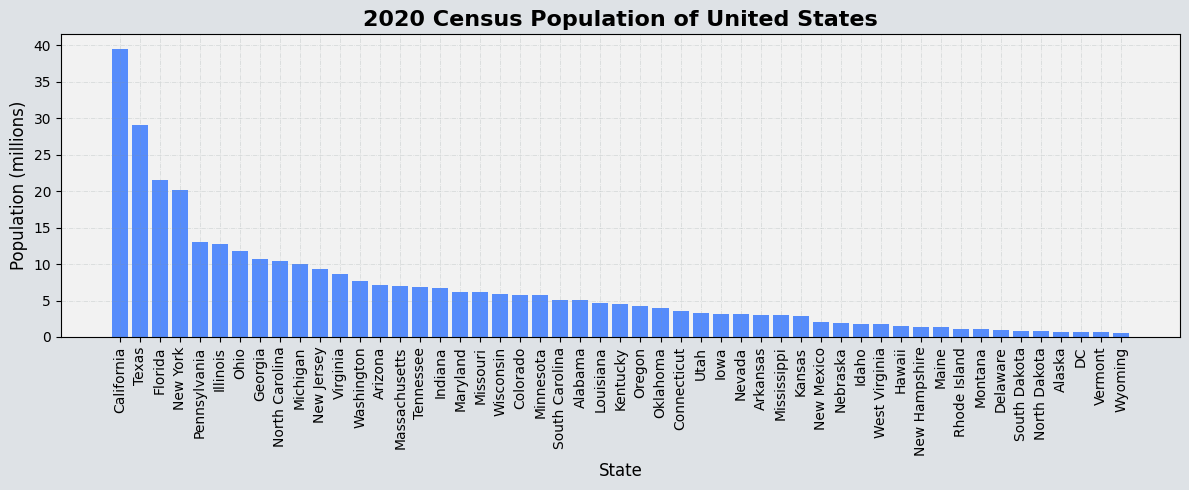

In [19]:
# Visualization of state population count (in millions)

# value counts
x = population["state"]
y = population["2020_census"] / 1000000 # simplifies the y-axis range of values

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#DEE2E6")
ax.set_facecolor('#F2F2F2')

plt.ticklabel_format(axis='y', style='plain')
plt.bar(x, y)

ax.set_xticks(range(51))
ax.set_xticklabels(x, rotation=90, ha="center")
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Population (millions)", fontsize=12)
ax.set_title("2020 Census Population of United States", fontsize=16, fontweight="bold")
ax.grid(alpha=0.3, linestyle='-.', color="#889696")

plt.tight_layout()
plt.show()

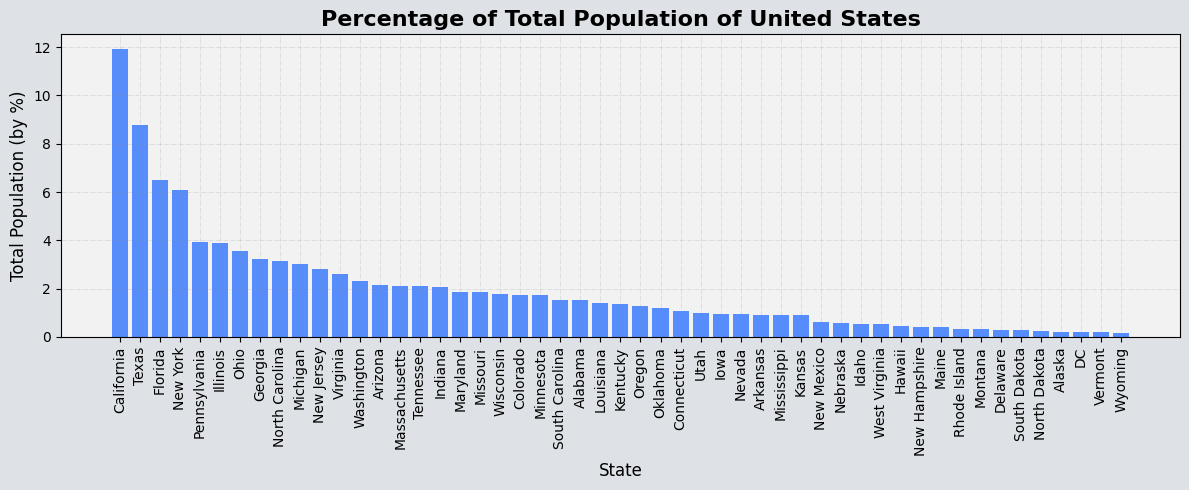

In [20]:
# Visualization of the percentage of the total U.S. population

# column values for x and y axis
x = population["state"]
y = population["percent_of_total"] * 100 # creates a percentage

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#DEE2E6")
ax.set_facecolor('#F2F2F2')

plt.ticklabel_format(axis='y', style='plain')
plt.bar(x, y)

ax.set_xticks(range(51))
ax.set_xticklabels(x, rotation=90, ha="center")
ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Total Population (by %)", fontsize=12)
ax.set_title("Percentage of Total Population of United States", fontsize=16, fontweight="bold")
ax.grid(alpha=0.3, linestyle='-.', color="#889696")

plt.tight_layout()
plt.show()